In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

In [2]:
df = pd.read_csv('../datasets/HDFS_v1/prepared_df.csv')
df['events_sequence'] = df['events_sequence'].apply(ast.literal_eval)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 575061 entries, 0 to 575060
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   blk_id           575061 non-null  str   
 1   events_sequence  575061 non-null  object
 2   Label            575061 non-null  int64 
dtypes: int64(1), object(1), str(1)
memory usage: 13.2+ MB


In [3]:
import numpy as np
from sklearn.model_selection import train_test_split

In [40]:
X, y = df['events_sequence'], df['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(len(X_train))
print(len(y_train))

460048
460048


In [41]:
train_seq_lengths = X_train.apply(len)
chosen_max_length = int(np.quantile(train_seq_lengths, 0.99))
print('Chosen max length: ', chosen_max_length)

Chosen max length:  33


### Truncating and padding
Sequences with less length than chosen max length will be padded with zero. Longer sequences will be truncated<br><br>

Since padding is done with 0, all events have to be shifted by 1 before padding. If event IDs started from 1, then shifting not needed

In [20]:
from torch.nn.utils.rnn import pad_sequence
import torch
import numpy as np

In [42]:
def process_X(X, max_length):
    X = [torch.tensor([x+1 for x in seq]) for seq in X]
    X = [seq[-max_length:] for seq in X]
    X = pad_sequence(X, batch_first=True, padding_value=0)

    return X

In [43]:
X_train = process_X(X_train, chosen_max_length)
X_test = process_X(X_test, chosen_max_length)

print(X_train.shape)
print(X_test.shape)

print(X_train[0], end='\n\n')
print(X_test[0])

torch.Size([460048, 33])
torch.Size([115013, 33])
tensor([ 1,  1,  2,  1,  3,  4,  3,  4,  5,  5,  3,  4,  5, 34, 34, 34, 17, 17,
        17,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

tensor([ 1,  5,  3,  4,  5,  5,  3,  4,  3,  4, 37, 37, 37, 37, 37, 37, 37, 37,
        37, 37, 37, 37, 37, 37, 10, 37, 13, 34, 34, 34, 17, 17, 17])


___
## FINALLY, Building a baseline LSTM

In [44]:
import torch.nn as nn

In [76]:
class Baseline(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size):
        super().__init__()

        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        h_last = h_n[-1]
        out = self.fc(h_last)
        return out.squeeze(1)

In [95]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vocab_size = max(X_train.max(), X_test.max()) + 1

baseline = Baseline(vocab_size, 64, 64).to(device)

In [79]:
from torch.utils.data import Dataset, DataLoader

In [80]:
class LogDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [81]:
y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32)

train = LogDataset(X_train, y_train)
test = LogDataset(X_test, y_test)

train_loader = DataLoader(dataset=train, batch_size=32, shuffle=True, num_workers=8, pin_memory=True, prefetch_factor=3, in_order=False)
test_loader = DataLoader(dataset=test, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, prefetch_factor=3, in_order=False)

TypeError: must be real number, not builtin_function_or_method

In [82]:
from tqdm import trange
from sklearn.metrics import roc_auc_score

In [83]:
y_pred.shape

torch.Size([1, 32, 1])

In [96]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(baseline.parameters(), lr=0.001, weight_decay=1e-5)
epochs = 5
baseline.train()

for epoch in trange(epochs):
    for X,y in train_loader:
        X,y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

        optimizer.zero_grad()

        y_pred = baseline(X)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()

100%|████████████████████████████████████████████████████████████████████| 5/5 [01:51<00:00, 22.24s/it]


In [97]:
baseline.eval()
all_labels, all_preds = [], []
with torch.no_grad():
    for X,y in test_loader:
        X,y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        
        y_pred = torch.sigmoid(baseline(X))

        all_labels.extend(y.cpu().numpy())
        all_preds.extend(y_pred.cpu().numpy())
        
print('Final roc-auc on test data: ', roc_auc_score(all_labels, all_preds))

Final roc-auc on test data:  0.9999951944091537


wtf, suspiciously high

In [89]:
from sklearn.metrics import classification_report

report = classification_report(all_labels, (np.array(all_preds) > 0.5).astype(int))
print(report)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    111645
         1.0       1.00      1.00      1.00      3368

    accuracy                           1.00    115013
   macro avg       1.00      1.00      1.00    115013
weighted avg       1.00      1.00      1.00    115013



___
#### Shuffling y_train labels to mess with learning to see if score drops to around 0.5 or not

In [90]:
perm = torch.randperm(len(y_train))
y_train_shuffled = y_train[perm]

In [91]:
shuffled_train = LogDataset(X_train, y_train_shuffled)
shuffled_train_loader = DataLoader(dataset=train, batch_size=32, shuffle=True, num_workers=8, pin_memory=True, prefetch_factor=3, in_order=False)

In [93]:
baseline_shuffled = Baseline(vocab_size, 64, 64).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(baseline.parameters(), lr=0.001, weight_decay=1e-5)
epochs = 5
baseline_shuffled.train()

for epoch in trange(epochs):
    for X,y in shuffled_train_loader:
        X,y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

        optimizer.zero_grad()

        y_pred = baseline_shuffled(X)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()

100%|████████████████████████████████████████████████████████████████████| 5/5 [01:30<00:00, 18.13s/it]


In [94]:
baseline_shuffled.eval()
all_labels, all_preds = [], []
with torch.no_grad():
    for X,y in test_loader:
        X,y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        
        y_pred = torch.sigmoid(baseline_shuffled(X))

        all_labels.extend(y.cpu().numpy())
        all_preds.extend(y_pred.cpu().numpy())
        
print('Final roc-auc on test data: ', roc_auc_score(all_labels, all_preds))

Final roc-auc on test data:  0.5884903280237274


Score on wrong labels is as expected
___

Im blown away by the baseline accuracy. Perhaps it does not generalize well. We will see. In the meantime, I will try tuning model to the maximum

___
## Training with tuned parameters

{'embed_dim': 128, 'hidden_size': 64, 'num_layers': 1, 'bidirectional': True, 'dropout': 0.32684737691194926, 'lr': 0.005796291605766127, 'weight_decay': 1.548800795410807e-05, 'optimizer': 'Adam', 'beta1': 0.8054818664442306, 'beta2': 0.9856392822301109}

In [113]:
X, y = df['events_sequence'], df['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, stratify=y_train, test_size=0.2, random_state=42)

max_length = 40

X_train = process_X(X_train, max_length)
X_val = process_X(X_val, max_length)
X_test = process_X(X_test, max_length)

y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_val = torch.tensor(y_val.values, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32)

train = LogDataset(X_train, y_train)
val = LogDataset(X_val, y_val)
test = LogDataset(X_test, y_test)

train_loader = DataLoader(train, batch_size=128, shuffle=True)
val_loader   = DataLoader(val, batch_size=128, shuffle=False)
test_loader   = DataLoader(test, batch_size=128, shuffle=False)

In [118]:
class TunedModel(nn.Module):
    def __init__(self, vocab_size=55):
        super().__init__()
        self.embed = nn.Embedding(num_embeddings=vocab_size, embedding_dim=128, padding_idx=0)
        self.lstm = nn.LSTM(input_size=128, hidden_size=64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
        self.fc = nn.Linear(64*2, 1)

    def forward(self, x):
        x = self.embed(x)
        _, (h_n, _) = self.lstm(x)
        
        h_forward = h_n[-2]
        h_backward = h_n[-1]
        h_last = torch.cat((h_forward, h_backward), dim=1)

        out = self.fc(h_last)
        return out.squeeze(1)

In [121]:
vocab_size = max(X_train.max(), X_test.max()) + 1
tuned_model = TunedModel(vocab_size).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(tuned_model.parameters(), lr=0.0058, weight_decay=1.55e-05, betas=(0.81, 0.985))
epochs = 80
best_loss = float('inf')
patience = 10
counter = 0 
min_delta = 2e-4
train_losses = []
val_losses = []

In [122]:
for epoch in trange(epochs):
    
    tuned_model.train()

    train_loss_epoch = 0
    for X,y in train_loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

        optimizer.zero_grad()

        y_preds = tuned_model(X)
        loss = loss_fn(y_preds, y)
        train_loss_epoch += loss.item()
        loss.backward()
        optimizer.step()
    train_losses.append(train_loss_epoch / len(train_loader))


    #Early stopping
    tuned_model.eval()
    val_loss_epoch = 0
    
    for X,y in val_loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

        with torch.no_grad():
            y_preds = tuned_model(X)
        loss = loss_fn(y_preds, y)
        val_loss_epoch += loss.item()
    val_loss_epoch /= len(val_loader)
    val_losses.append(val_loss_epoch)

    if val_loss_epoch < best_loss - min_delta:
        best_loss = val_loss_epoch
        best_epoch = epoch
        counter = 0
        torch.save({
            'epoch':epoch,
            'model_state':tuned_model.state_dict(),
            'optimizer_state':optimizer.state_dict(),
            'best_loss':best_loss,
            'counter':counter
        }, 'checkpoint.pth')

    else:
        counter += 1
        if counter >= patience:
            print(f'Early stopping triggered, validation loss has not improved after {patience} rounds.\nBest epoch: {best_epoch}\nBest loss: {best_loss}')
            break

    tuned_model.train()

 30%|███████████████████▊                                              | 24/80 [05:13<12:11, 13.06s/it]

Early stopping triggered, validation loss has not improved after 10 rounds.
Best epoch: 14
Best loss: 0.0014379534774543851


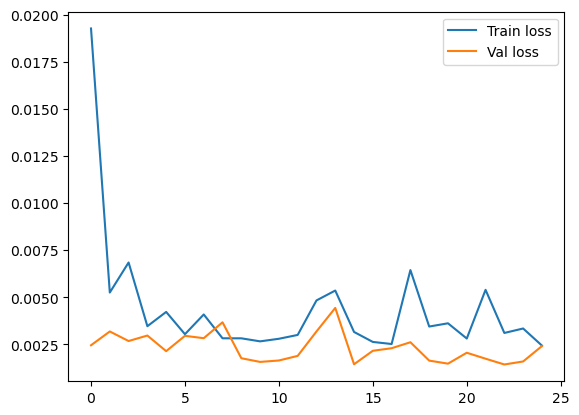

In [124]:
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.legend()
plt.savefig('Train VS Val loss.png', dpi=200, format='png')
plt.show()

In [126]:
checkpoint = torch.load('checkpoint.pth')
tuned_model.load_state_dict(checkpoint['model_state'])

<All keys matched successfully>

In [130]:
#Testing on test data

all_labels, all_preds = [], []

for X,y in test_loader:
    X,y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

    tuned_model.eval()
    
    with torch.no_grad():
        y_preds = torch.sigmoid(tuned_model(X))

        all_preds.extend(y_preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

print("Final tuned model's score on test data: ", roc_auc_score(all_labels, all_preds))

Final tuned model's score on test data:  0.9999083586856838


In [131]:
torch.save(tuned_model.state_dict(), 'final_model.pt')